# Instrument response removal without obspy

`seisfetch.contrib.response` removes instrument response with **numpy + stdlib
XML only** — no obspy, no compiled evalresp. This notebook compares four
removal paths on a real record and shows the residuals in time and frequency:

| Label | Path | Stabilization |
|---|---|---|
| **obspy** | `Trace.remove_response` (compiled evalresp) | 60 dB water level |
| **full** | `remove_response_np(mode="full")` — every stage evaluated | 60 dB water level |
| **paz** | `remove_response_np(mode="paz")` — stage-1 poles/zeros × sensitivity | 60 dB water level |
| **translate** | `translate_resp_np` — SeisIO.jl-style translation to a flat target | ε-guard, no water level |

The translation output is broadband by design; for the comparisons below it is
band-limited with the same raised-cosine `pre_filt` as the other methods so
all four traces occupy the same band.

Data: the committed test fixtures — `tests/bench.mseed` is CI.PASC.00.BHZ on
**2011-03-11**, the Tōhoku M9.1 day (40 Hz, 6.9 M samples), and
`tests/fixtures/CI_PASC_00_BHZ.xml` carries the matching response epoch
(analog poles/zeros → digitizer gain → 39-tap FIR). Everything runs offline.

Full validation numbers and the evalresp A0 discovery live in
[`docs/response-removal-design.md`](../docs/response-removal-design.md) and
`tests/precision/test_response_equivalence.py`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from seisfetch.contrib.response import (
    _npts2nfft,
    cosine_sac_taper_np,
    evaluate_response,
    parse_stationxml_response,
    remove_response_np,
    translate_resp_np,
)
from seisfetch.convert import parse_mseed

ROOT = Path("..") if Path.cwd().name == "notebooks" else Path(".")
RAW = (ROOT / "tests" / "bench.mseed").read_bytes()
XML = (ROOT / "tests" / "fixtures" / "CI_PASC_00_BHZ.xml").read_bytes()

seg = parse_mseed(RAW).segments()["CI.PASC.00.BHZ"][0]
fs = seg.sampling_rate
npts = int(24 * 3600 * fs)  # the fixture holds two contiguous days; keep day one
data = seg.data[:npts].astype(np.float64)
resp = parse_stationxml_response(XML, "CI", "PASC", "00", "BHZ", "2011-03-11T12:00:00")
print(
    f"CI.PASC.00.BHZ  {npts:,} samples @ {fs:g} Hz | "
    f"{len(resp.stages)} response stages | sensitivity {resp.sensitivity:.4g}"
)

# validated categorical palette, fixed slot order
C = {"obspy": "#2a78d6", "full": "#eb6834", "paz": "#1baf7a", "translate": "#eda100"}
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linewidth": 0.5,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 9.5,
    }
)

CI.PASC.00.BHZ  3,456,000 samples @ 40 Hz | 4 response stages | sensitivity 4.302e+09


## The response itself

`mode="full"` evaluates every stage (verified to 1.6×10⁻¹⁰ against compiled
evalresp); `mode="paz"` is the classic SACPZ shortcut — stage-1 poles/zeros ×
overall sensitivity. Their disagreement is exactly the FIR anti-alias chain.

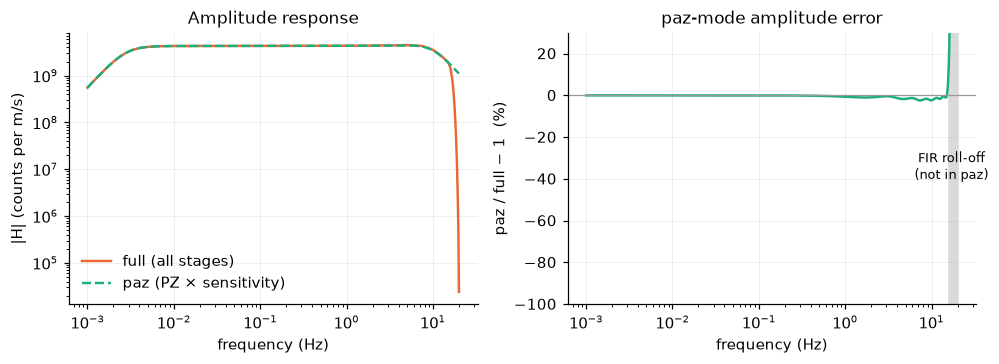

In [2]:
freqs = np.logspace(-3, np.log10(19.99), 2000)
H_full = evaluate_response(freqs, resp, output="VEL", mode="full")
H_paz = evaluate_response(freqs, resp, output="VEL", mode="paz")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.2, 3.4))
ax1.loglog(freqs, np.abs(H_full), color=C["full"], lw=1.6, label="full (all stages)")
ax1.loglog(
    freqs,
    np.abs(H_paz),
    color=C["paz"],
    lw=1.6,
    ls="--",
    label="paz (PZ × sensitivity)",
)
ax1.set_xlabel("frequency (Hz)")
ax1.set_ylabel("|H| (counts per m/s)")
ax1.set_title("Amplitude response")
ax1.legend(frameon=False)

ratio = np.abs(H_paz) / np.abs(H_full)
ax2.semilogx(freqs, 100 * (ratio - 1), color=C["paz"], lw=1.6)
ax2.axhline(0, color="0.6", lw=0.8)
ax2.axvspan(16, 20, color="0.85", zorder=0)
ax2.annotate("FIR roll-off\n(not in paz)", xy=(17, -40), fontsize=8.5, ha="center")
ax2.set_xlabel("frequency (Hz)")
ax2.set_ylabel("paz / full − 1  (%)")
ax2.set_ylim(-100, 30)
ax2.set_title("paz-mode amplitude error")
fig.tight_layout()

## Remove the response four ways

Common parameters: `output="VEL"`, `pre_filt = (0.005, 0.01, 18.0, 19.8)  # broadband: keep the surface waves`,
60 dB water level (except translation, which stabilizes via its target).
The obspy path needs obspy installed — it is the reference, not a dependency.

In [3]:
import io

import obspy

pre_filt = (0.005, 0.01, 18.0, 19.8)  # broadband: keep the surface waves
inv = obspy.read_inventory(io.BytesIO(XML))
tr = obspy.Trace(data.copy())
tr.stats.sampling_rate = fs
tr.stats.network, tr.stats.station = "CI", "PASC"
tr.stats.location, tr.stats.channel = "00", "BHZ"
tr.stats.starttime = obspy.UTCDateTime("2011-03-11T00:00:00")
tr.remove_response(inventory=inv, output="VEL", water_level=60, pre_filt=pre_filt)

out = {"obspy": tr.data}
out["full"] = remove_response_np(
    data, fs, resp, output="VEL", water_level=60, pre_filt=pre_filt, mode="full"
)
out["paz"] = remove_response_np(
    data, fs, resp, output="VEL", water_level=60, pre_filt=pre_filt, mode="paz"
)
# translate is broadband by design (no pre_filt); band-limit it with the
# SAME raised-cosine so all four traces occupy the same band for comparison
tl = translate_resp_np(data - data.mean(), fs, resp, mode="full")
nfft = _npts2nfft(tl.shape[0])
fgrid = np.linspace(0.0, fs / 2.0, nfft // 2 + 1)
spec = np.fft.rfft(tl, n=nfft) * cosine_sac_taper_np(fgrid, pre_filt)
out["translate"] = np.fft.irfft(spec)[: tl.shape[0]]

for k, v in out.items():
    print(f"{k:10s} peak |v| = {np.abs(v).max():.3e} m/s")

/Users/marinedenolle/GitHub/seisfetch/.pixi/envs/default/lib/python3.12/site-packages/obspy/core/inventory/util.py:1129: UserWarning: Given string seems to not be a valid URI: 'CI'
  warnings.warn(msg)


obspy      peak |v| = 1.279e-03 m/s
full       peak |v| = 1.279e-03 m/s
paz        peak |v| = 1.279e-03 m/s
translate  peak |v| = 1.279e-03 m/s


## Waveforms

Top: the raw day in counts. Bottom: the corrected velocity seismograms zoomed
on the Tōhoku wave train (P through surface waves), offset vertically so each
method is visible. At this scale the four are indistinguishable — the
differences live in the residual panels below.

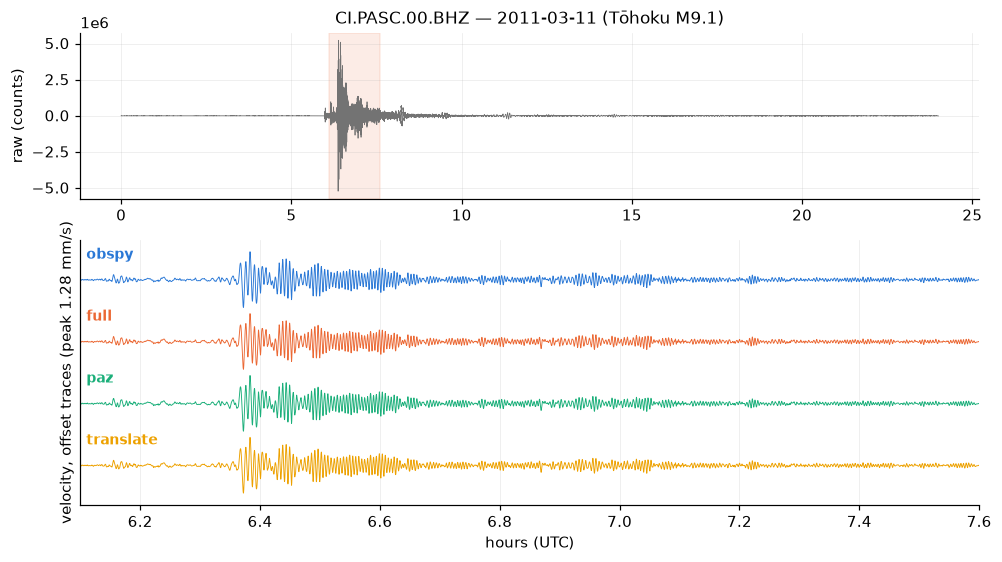

In [4]:
t_h = np.arange(npts) / fs / 3600.0
zoom = slice(int(6.1 * 3600 * fs), int(7.6 * 3600 * fs))

fig, (ax0, ax1) = plt.subplots(
    2, 1, figsize=(9.2, 5.2), gridspec_kw={"height_ratios": [1, 1.6]}
)
step = 25  # decimate for plotting only
ax0.plot(t_h[::step], data[::step], color="0.45", lw=0.5)
ax0.axvspan(t_h[zoom.start], t_h[zoom.stop], color="#eb6834", alpha=0.12)
ax0.set_ylabel("raw (counts)")
ax0.set_title("CI.PASC.00.BHZ — 2011-03-11 (Tōhoku M9.1)")

scale = np.abs(out["obspy"][zoom]).max()
for i, k in enumerate(("obspy", "full", "paz", "translate")):
    off = -i * 2.2 * scale
    ax1.plot(t_h[zoom][::4], out[k][zoom][::4] + off, color=C[k], lw=0.6)
    ax1.text(
        t_h[zoom.start] + 0.01,
        off + 0.75 * scale,
        k,
        color=C[k],
        fontsize=9,
        fontweight="bold",
    )
ax1.set_xlim(t_h[zoom.start], t_h[zoom.stop])
ax1.set_yticks([])
ax1.set_xlabel("hours (UTC)")
ax1.set_ylabel(f"velocity, offset traces (peak {scale*1e3:.2f} mm/s)")
fig.tight_layout()

## Residuals vs the obspy reference — time domain

Plotted as the ratio of the residual envelope to the reference peak
(1-minute maxima, log scale). `full` sits at float64 machine precision
(~10⁻¹⁶): it *is* obspy's algorithm. `paz` differs at the ~0.1–1% level (the unmodeled
FIR stages); `translate` differs at the percent level through the taper and
stabilization choices — physical differences, not numerical ones.

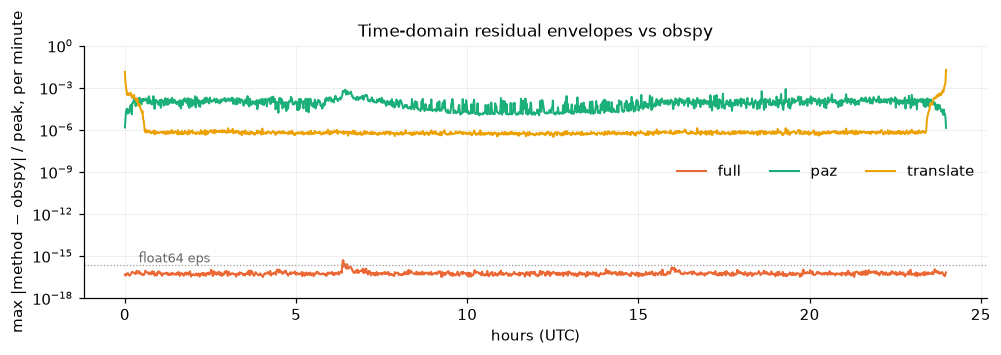

In [5]:
peak = np.abs(out["obspy"]).max()
win = int(60 * fs)  # 1-minute envelope
nwin = npts // win

fig, ax = plt.subplots(figsize=(9.2, 3.2))
for k in ("full", "paz", "translate"):
    r = np.abs(out[k] - out["obspy"])[: nwin * win].reshape(nwin, win).max(axis=1)
    ax.semilogy(np.arange(nwin) / 60.0, r / peak, color=C[k], lw=1.3, label=k)
ax.axhline(np.finfo(np.float64).eps, color="0.6", lw=0.8, ls=":")
ax.annotate(
    "float64 eps", xy=(0.4, np.finfo(np.float64).eps * 1.6), fontsize=8.5, color="0.4"
)
ax.set_xlabel("hours (UTC)")
ax.set_ylabel("max |method − obspy| / peak, per minute")
ax.set_ylim(1e-18, 1)
ax.set_title("Time-domain residual envelopes vs obspy")
ax.legend(frameon=False, ncols=3)
fig.tight_layout()

## Residuals — frequency domain

Left: amplitude spectra of the corrected traces (smoothed) — the four
overlay. Right: the residual spectrum relative to the reference spectrum.
`full` floats at 10⁻¹⁵–10⁻¹²: machine precision. `paz` grows from 10⁻⁴ at
long periods to the percent level at the FIR corner — exactly the unmodeled
anti-alias chain. `translate` reads high wherever the signal spectrum is weak
because it uses a different time window (no SAC taper) and stabilization; its
time-domain residual is still ~10⁻⁶ of peak (previous figure). None of these
are numerical errors — they are the documented physical differences between
the methods.

/var/folders/js/lzmy975n0l5bjbmr9db291m00000gn/T/ipykernel_22816/2713000130.py:30: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()


/Users/marinedenolle/GitHub/seisfetch/.pixi/envs/default/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


/Users/marinedenolle/GitHub/seisfetch/.pixi/envs/default/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


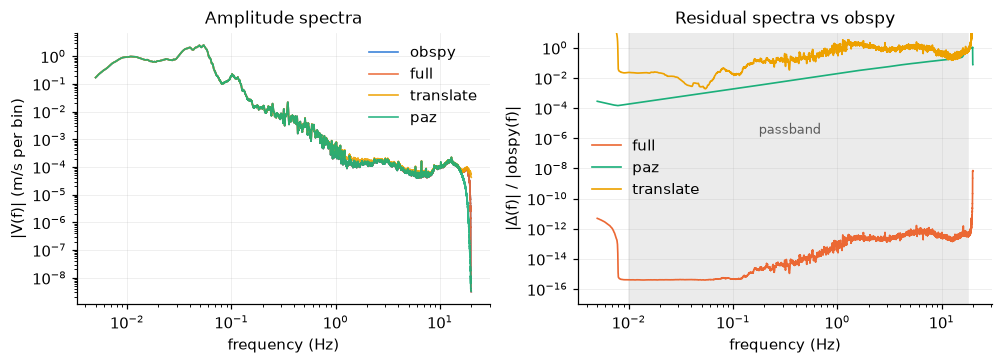

In [6]:
from numpy.fft import rfft, rfftfreq

F = rfftfreq(npts, 1 / fs)
S = {k: np.abs(rfft(v)) for k, v in out.items()}
R = {k: np.abs(rfft(out[k] - out["obspy"])) for k in ("full", "paz", "translate")}


def smooth(x, m=501):
    k = np.ones(m) / m
    return np.convolve(x, k, mode="same")


sel = (F > 5e-3) & (F < 19.9)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.2, 3.4))
for k in ("obspy", "full", "translate", "paz"):
    ax1.loglog(F[sel], smooth(S[k])[sel], color=C[k], lw=1.1, label=k, alpha=0.9)
ax1.set_xlabel("frequency (Hz)")
ax1.set_ylabel("|V(f)| (m/s per bin)")
ax1.set_title("Amplitude spectra")
ax1.legend(frameon=False)

for k in ("full", "paz", "translate"):
    ax2.loglog(
        F[sel],
        smooth(R[k] / np.maximum(S["obspy"], 1e-300))[sel],
        color=C[k],
        lw=1.1,
        label=k,
    )
ax2.axvspan(0.01, 18, color="0.92", zorder=0)
ax2.annotate("passband", xy=(0.35, 2e-6), fontsize=8.5, color="0.35", ha="center")
ax2.set_xlabel("frequency (Hz)")
ax2.set_ylabel("|Δ(f)| / |obspy(f)|")
ax2.set_ylim(1e-17, 1e1)
ax2.set_title("Residual spectra vs obspy")
ax2.legend(frameon=False)
fig.tight_layout()

## Summary

| Method | Max residual vs obspy (of peak) | When to use |
|---|---|---|
| `full` + water level | ~10⁻¹⁶ — machine precision | default: it is evalresp + obspy's algorithm, without obspy |
| `paz` + water level | ~1% below 4 Hz; grows near Nyquist | SACPZ-style metadata, low-frequency bands only |
| `translate` (flat) | band-edge differences by design | SeisIO.jl-compatible workflows; translating a network to a common target instrument |

The evaluator matches compiled evalresp to 1.6×10⁻¹⁰ — including the
undocumented behavior that evalresp **ignores the XML `NormalizationFactor`
and recomputes A0 at the stage gain's frequency** (0.22% amplitude on this
station's 2007 epoch if you trust the XML instead). See
`docs/response-removal-design.md` for the dissection and
`tests/precision/test_response_equivalence.py` for the assertions.